In [1]:
# === Cellule 1 ===
import pandas as pd
import numpy as np
import os

# Pour voir le dossier courant
print("Dossier courant :", os.getcwd())

# Chemins vers les fichiers (à adapter si besoin)
path_75 = "Data/dep75.xlsx"
path_69 = "Data/dep69.xlsx"
path_33 = "Data/dep33.xlsx"
path_64 = "Data/dep64.xlsx"

Dossier courant : /Users/saife/Desktop/Data science


In [2]:
# === Cellule 2 ===
def load_insee_communes(path):
    """
    Lit un fichier INSEE (feuille 'Communes') et renvoie un DataFrame propre :
    colonnes : ['departement','code_commune','commune','population_municipale','population_totale']
    """
    # Charger la feuille
    df_raw = pd.read_excel(path, sheet_name="Communes", header=None, dtype=str)
    
    # Trouver la ligne d’en-tête (celle qui contient 'Nom de la commune')
    header_idx = None
    for i in range(20):
        row = " | ".join(df_raw.iloc[i].fillna("").astype(str).tolist()).lower()
        if "nom de la commune" in row and "population municipale" in row:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Ligne d’en-tête non trouvée dans {path}")
    
    # Lire à partir de cette ligne
    df = pd.read_excel(path, sheet_name="Communes", header=header_idx)
    
    # Sélectionner les colonnes clés
    cols = [
        "Code département",
        "Code commune",
        "Nom de la commune",
        "Population municipale",
        "Population totale"
    ]
    df = df[[c for c in cols if c in df.columns]].copy()
    
    # Renommer pour standardiser
    df.columns = ["departement", "code_commune", "commune", "population_municipale", "population_totale"]
    
    # Nettoyage des chiffres
    for col in ["population_municipale", "population_totale"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("\u202f", "", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.extract(r"([\d\.]+)", expand=False)
            .astype(float)
        )

    # Supprimer les lignes vides ou avec entêtes résiduels
    df = df.dropna(subset=["commune"])
    df = df[~df["commune"].str.contains("Nom de la commune|Code", case=False, na=False)]
    
    return df.reset_index(drop=True)

In [3]:
# === Cellule 3 ===
pop_75 = load_insee_communes(path_75)
pop_69 = load_insee_communes(path_69)
pop_33 = load_insee_communes(path_33)
pop_64 = load_insee_communes(path_64)

print("✅ Fichiers chargés avec succès !")
print("Paris :", pop_75.shape, "Lyon :", pop_69.shape, "Bordeaux :", pop_33.shape, "Pays-Basque :", pop_64.shape)

/Users/saife/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/saife/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/saife/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/saife/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/saife/Library/Python/3.9/lib/python/site-pack

✅ Fichiers chargés avec succès !
Paris : (20, 5) Lyon : (275, 5) Bordeaux : (535, 5) Pays-Basque : (546, 5)


In [4]:
# === Cellule 4 ===
# Paris = somme des arrondissements
paris_total = pd.DataFrame({
    "commune": ["Paris"],
    "population_municipale": [pop_75["population_municipale"].sum()],
    "population_totale": [pop_75["population_totale"].sum()],
    "departement": ["75"]
})

# Lyon
lyon = pop_69[pop_69["commune"].str.fullmatch("Lyon", case=False, na=False)]

# Bordeaux
bordeaux = pop_33[pop_33["commune"].str.fullmatch("Bordeaux", case=False, na=False)]

# Pays basque (Bayonne, Biarritz, Anglet)
pb = pop_64[pop_64["commune"].isin(["Bayonne", "Biarritz", "Anglet"])]

# Concaténation
pop_focus = pd.concat([paris_total, lyon, bordeaux, pb], ignore_index=True)

# Réorganisation des colonnes
pop_focus = pop_focus[["commune", "population_municipale", "population_totale", "departement"]]

pop_focus

,commune,population_municipale,population_totale,departement
0,Paris,2133111.0,2149216.0,75
1,Bordeaux,261804.0,265255.0,33
2,Anglet,41153.0,42228.0,64
3,Bayonne,52749.0,54029.0,64
4,Biarritz,25764.0,26435.0,64


In [5]:
# === Cellule A : Ajouter Lyon ===
mask_lyon = pop_69["commune"].str.contains(r"^Lyon(\s|\b|\Z)|^Lyon\s?\d{1,2}(er|e)?\b", case=False, na=False)

if mask_lyon.any():
    lyon_total = pd.DataFrame({
        "commune": ["Lyon"],
        "population_municipale": [pop_69.loc[mask_lyon, "population_municipale"].sum()],
        "population_totale": [pop_69.loc[mask_lyon, "population_totale"].sum() if "population_totale" in pop_69 else None],
        "departement": ["69"]
    })
else:
    lyon_rows = pop_69[pop_69["commune"].str.fullmatch("Lyon", case=False, na=False)]
    if not lyon_rows.empty:
        lyon_total = lyon_rows.assign(departement="69")[["commune","population_municipale","population_totale","departement"]]
    else:
        raise ValueError("Impossible de trouver Lyon dans dep69.xlsx — regarde la colonne 'commune' de pop_69.head()")

pop_focus = pd.concat([pop_focus, lyon_total], ignore_index=True)

/var/folders/4q/0tb1xphx4c15tdbv715nm6500000gn/T/ipykernel_73169/3564667409.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_lyon = pop_69["commune"].str.contains(r"^Lyon(\s|\b|\Z)|^Lyon\s?\d{1,2}(er|e)?\b", case=False, na=False)


In [6]:
# === Cellule B : Nettoyage final ===
for c in ["population_municipale", "population_totale"]:
    if c in pop_focus:
        pop_focus[c] = pop_focus[c].round().astype("Int64")

pop_focus["departement"] = pop_focus["departement"].astype(str)

ordre = ["Paris","Lyon","Bordeaux","Bayonne","Biarritz","Anglet"]
pop_focus["commune"] = pd.Categorical(pop_focus["commune"], categories=ordre, ordered=True)
pop_focus = pop_focus.sort_values("commune").reset_index(drop=True)

pd.options.display.float_format = "{:,.0f}".format
pop_focus

,commune,population_municipale,population_totale,departement
0,Paris,2133111,2149216,75
1,Lyon,522250,528550,69
2,Bordeaux,261804,265255,33
3,Bayonne,52749,54029,64
4,Biarritz,25764,26435,64
5,Anglet,41153,42228,64


In [7]:
# === Cellule 5 ===
pop_focus.to_csv("insee_population_focus.csv", index=False, encoding="utf-8")
print("✅ Fichier 'insee_population_focus.csv' sauvegardé avec succès !")

✅ Fichier 'insee_population_focus.csv' sauvegardé avec succès !


In [8]:
!pip3 install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


    commune  population_municipale  population_totale departement
0     Paris                2133111            2149216          75
1      Lyon                 522250             528550          69
2  Bordeaux                 261804             265255          33
3   Bayonne                  52749              54029          64
4  Biarritz                  25764              26435          64
5    Anglet                  41153              42228          64


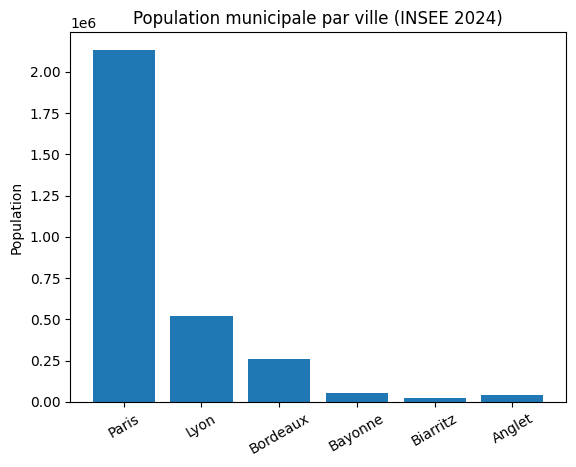

In [9]:
# === Cellule 6 ===
import matplotlib.pyplot as plt

print(pop_focus)

plt.bar(pop_focus["commune"], pop_focus["population_municipale"])
plt.title("Population municipale par ville (INSEE 2024)")
plt.ylabel("Population")
plt.xticks(rotation=30)
plt.show()

### Charger le comparateur INSEE (socio-éco)

In [11]:
# === Cellule 7 : chargement comparateur INSEE (socio-éco) ===
import pandas as pd
import numpy as np

path_comp = "Data/base_cc_comparateur_csv/base_cc_comparateur.csv"  # adapter le chemin si besoin

dfc = pd.read_csv(path_comp, sep=";", low_memory=False, dtype=str)

# Colonnes utiles (si certaines manquent dans ta version, on ignore)
cols_use = ["LIBGEO","CODGEO","P22_POP","MED21","TP6021","P22_CHOM1564","P22_LOG","P22_RP","P22_LOGVAC","SUPERF"]
cols_use = [c for c in cols_use if c in dfc.columns]
dfc = dfc[cols_use].copy()

print("Aperçu comparateur :", dfc.shape)
dfc.head()

Aperçu comparateur : (34988, 9)


,CODGEO,P22_POP,MED21,TP6021,P22_CHOM1564,P22_LOG,P22_RP,P22_LOGVAC,SUPERF
0,01001,859,25820,s,28,379,354,14,15.95
1,01002,273,24480,s,2,175,121,13,9.15
2,01004,15554,21660,"17,0",1005.74464122363,7973.37070832312,7107.01247632609,741.215107871097,24.6
3,01005,1917,24610,s,63.3233972939973,920.955244744725,814.669984514292,98.5352933386311,15.92
4,01006,114,24210,s,5,71,57,6,5.88


In [15]:
# === Cellule 7.1 : diagnostic colonnes ===
print("Colonnes disponibles :", list(dfc.columns))

Colonnes disponibles : ['CODGEO', 'P22_POP', 'MED21', 'TP6021', 'P22_CHOM1564', 'P22_LOG', 'P22_RP', 'P22_LOGVAC', 'SUPERF']


In [13]:
# === Cellule 8 (robuste) : nettoyage numériques ===
import re
import numpy as np

num_cols = [c for c in ["P22_POP","MED21","TP6021","P22_CHOM1564","P22_LOG","P22_RP","P22_LOGVAC","SUPERF"] if c in dfc.columns]

# 1) remplacer quelques marqueurs textuels courants par NaN
dfc[num_cols] = dfc[num_cols].replace(
    {
        "s": np.nan, "S": np.nan,
        "nd": np.nan, "ND": np.nan,
        "na": np.nan, "NA": np.nan,
        "n.d": np.nan, "N.D": np.nan,
        "": np.nan
    }
)

# 2) fonction de nettoyage valeur par valeur
def _clean_num_series(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    # enlever espaces (y compris insécables) et % et autres symboles
    s = (s.str.replace("\u202f","", regex=False)
           .str.replace(" ","", regex=False)
           .str.replace("%","", regex=False))
    # virgule -> point
    s = s.str.replace(",",".", regex=False)
    # garder uniquement chiffres, point, signe moins (ex: -1.23)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True)
    # conversion en float (coerce en NaN si encore non numérique)
    return pd.to_numeric(s, errors="coerce")

for col in num_cols:
    dfc[col] = _clean_num_series(dfc[col])

# (Optionnel) diagnostic rapide : quelles valeurs non converties restaient ?
# for col in num_cols:
#     bad = dfc[col].isna() & dfc[col].astype(str).ne("nan")
#     if bad.any():
#         print(col, "→", dfc.loc[bad, col].head().tolist())

dfc.head(3)

,CODGEO,P22_POP,MED21,TP6021,P22_CHOM1564,P22_LOG,P22_RP,P22_LOGVAC,SUPERF
0,01001,859,"25,820",NaN,28,379,354,14,16
1,01002,273,"24,480",NaN,2,175,121,13,9
2,01004,"15,554","21,660",17,"1,006","7,973","7,107",741,25


In [17]:
# === Cellule 9 (corrigée) : mapping commune -> CODGEO (5 chiffres) ===

def get_codgeo(df, name, default_dep=None):
    """
    Cherche une ligne dont 'commune' == name.
    Construit le CODGEO = departement + code_commune (zfill 3).
    Si 'departement' n'est pas dispo, utilise default_dep si fourni.
    """
    m = df[df["commune"].str.fullmatch(name, case=False, na=False)]
    if m.empty:
        return None

    # code_commune (3 chiffres)
    if "code_commune" not in m.columns:
        return None
    cc = str(m.iloc[0]["code_commune"]).strip()
    cc = cc.zfill(3)  # ex: "063" pour Bordeaux

    # departement
    if "departement" in m.columns and pd.notna(m.iloc[0]["departement"]):
        dep = str(m.iloc[0]["departement"]).strip()
        # garder "75", "33", "64", "69", etc. (2 ou 3 caractères selon Corse/DOM)
        dep = "".join([ch for ch in dep if ch.isdigit()])  # simpliste mais robuste ici
    else:
        dep = str(default_dep) if default_dep else None

    if not dep:
        return None

    return f"{dep}{cc}"

codes = {}

# Paris : agrégation arrondissements -> code commune unique
codes["Paris"] = "75056"

# Lyon : selon ton fichier, il peut y avoir "Lyon" ou des arrondissements
# on tente d'abord une ligne "Lyon" exacte, sinon on met le code connu
lyon_cod = get_codgeo(pop_69, "Lyon", default_dep=69)
if lyon_cod is None:
    lyon_cod = "69123"  # code INSEE officiel de Lyon
codes["Lyon"] = lyon_cod

# Bordeaux (dep33)
codes["Bordeaux"] = get_codgeo(pop_33, "Bordeaux", default_dep=33) or "33063"

# Pays basque (dep64)
codes["Bayonne"]  = get_codgeo(pop_64, "Bayonne",  default_dep=64) or "64102"
codes["Biarritz"] = get_codgeo(pop_64, "Biarritz", default_dep=64) or "64122"
codes["Anglet"]   = get_codgeo(pop_64, "Anglet",   default_dep=64) or "64024"

print("Mapping commune -> CODGEO (INSEE) :")
for k,v in codes.items():
    print(f"  {k} -> {v}")

missing = [k for k,v in codes.items() if not v]
if missing:
    raise ValueError(f"Codes manquants pour : {missing}. Vérifie le contenu des pop_XX.")

Mapping commune -> CODGEO (INSEE) :
  Paris -> 75056
  Lyon -> 69123
  Bordeaux -> 33063
  Bayonne -> 64102
  Biarritz -> 64122
  Anglet -> 64024


In [18]:
# === Cellule 9bis : filtrage par codes INSEE dans le comparateur ===
target_codes = [v for v in codes.values() if v]

df_insee = dfc[dfc["CODGEO"].astype(str).isin(target_codes)].copy()

# Remettre le nom de la commune depuis le mapping inverse
code_to_name = {v:k for k,v in codes.items() if v}
df_insee["commune"] = df_insee["CODGEO"].astype(str).map(code_to_name)

# Renommer les colonnes utiles si elles existent
rename_map = {
    "P22_POP":"population_2022",
    "MED21":"revenu_median_2021",
    "TP6021":"taux_pauvrete_2021",
    "P22_CHOM1564":"taux_chomage_15_64",
    "P22_LOG":"nb_logements_2022",
    "P22_RP":"nb_res_principales_2022",
    "P22_LOGVAC":"nb_logements_vacants_2022",
    "SUPERF":"superficie_km2"
}
df_insee = df_insee.rename(columns={k:v for k,v in rename_map.items() if k in df_insee.columns})

final_cols = [c for c in ["commune","population_2022","revenu_median_2021","taux_pauvrete_2021",
                          "taux_chomage_15_64","nb_logements_2022","nb_res_principales_2022",
                          "nb_logements_vacants_2022","superficie_km2","CODGEO"] if c in df_insee.columns]
df_insee = df_insee[final_cols].reset_index(drop=True)

df_insee

,commune,population_2022,revenu_median_2021,taux_pauvrete_2021,taux_chomage_15_64,nb_logements_2022,nb_res_principales_2022,nb_logements_vacants_2022,superficie_km2,CODGEO
0,Bordeaux,"265,328","24,870",17,"16,952","168,458","146,517","12,026",49,33063
1,Anglet,"42,288","25,060",10,"2,026","28,600","22,953","1,170",27,64024
2,Bayonne,"53,312","21,780",17,"2,928","32,855","29,620","1,756",22,64102
3,Biarritz,"25,810","25,640",13,"1,299","26,387","15,078",560,12,64122
4,Lyon,"520,774","25,430",16,"30,486","318,612","271,602","28,461",48,69123
5,Paris,"2,113,705","29,730",16,"121,919","1,399,122","1,125,473","136,957",105,75056


In [19]:
# === Cellule 10 : fusion démographie (pop_focus) + socio-éco (df_insee) ===
# On conserve la population municipale d'INSEE 2024 (pop_focus) et on ajoute les socio-éco
df_merged = pop_focus.merge(df_insee, on="commune", how="left")

# Indicateurs utiles
if {"population_2022","superficie_km2"}.issubset(df_merged.columns):
    df_merged["densite_hab_km2"] = (df_merged["population_2022"] / df_merged["superficie_km2"]).round(1)

if {"nb_logements_2022","nb_res_principales_2022","nb_logements_vacants_2022"}.issubset(df_merged.columns):
    df_merged["taux_vacance_%"] = (100 * df_merged["nb_logements_vacants_2022"] / df_merged["nb_logements_2022"]).round(2)
    df_merged["part_res_principales_%"] = (100 * df_merged["nb_res_principales_2022"] / df_merged["nb_logements_2022"]).round(2)

# Ordonner
ordre = ["Paris","Lyon","Bordeaux","Bayonne","Biarritz","Anglet"]
df_merged["commune"] = pd.Categorical(df_merged["commune"], categories=ordre, ordered=True)
df_merged = df_merged.sort_values("commune").reset_index(drop=True)

df_merged

,commune,population_municipale,population_totale,departement,population_2022,revenu_median_2021,taux_pauvrete_2021,taux_chomage_15_64,nb_logements_2022,nb_res_principales_2022,nb_logements_vacants_2022,superficie_km2,CODGEO,densite_hab_km2,taux_vacance_%,part_res_principales_%
0,Paris,2133111,2149216,75,"2,113,705","29,730",16,"121,919","1,399,122","1,125,473","136,957",105,75056,"20,054",10,80
1,Lyon,522250,528550,69,"520,774","25,430",16,"30,486","318,612","271,602","28,461",48,69123,"10,879",9,85
2,Bordeaux,261804,265255,33,"265,328","24,870",17,"16,952","168,458","146,517","12,026",49,33063,"5,375",7,87
3,Bayonne,52749,54029,64,"53,312","21,780",17,"2,928","32,855","29,620","1,756",22,64102,"2,459",5,90
4,Biarritz,25764,26435,64,"25,810","25,640",13,"1,299","26,387","15,078",560,12,64122,"2,214",2,57
5,Anglet,41153,42228,64,"42,288","25,060",10,"2,026","28,600","22,953","1,170",27,64024,"1,570",4,80


In [20]:
# === Cellule 11 : synthèse ===
cols_show = ["commune","population_municipale","revenu_median_2021","taux_pauvrete_2021",
             "taux_chomage_15_64","densite_hab_km2","taux_vacance_%","part_res_principales_%"]

cols_show = [c for c in cols_show if c in df_merged.columns]
display(df_merged[cols_show])

,commune,population_municipale,revenu_median_2021,taux_pauvrete_2021,taux_chomage_15_64,densite_hab_km2,taux_vacance_%,part_res_principales_%
0,Paris,2133111,"29,730",16,"121,919","20,054",10,80
1,Lyon,522250,"25,430",16,"30,486","10,879",9,85
2,Bordeaux,261804,"24,870",17,"16,952","5,375",7,87
3,Bayonne,52749,"21,780",17,"2,928","2,459",5,90
4,Biarritz,25764,"25,640",13,"1,299","2,214",2,57
5,Anglet,41153,"25,060",10,"2,026","1,570",4,80


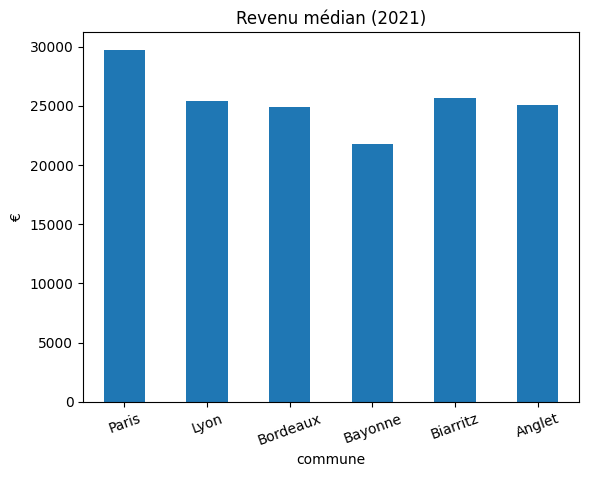

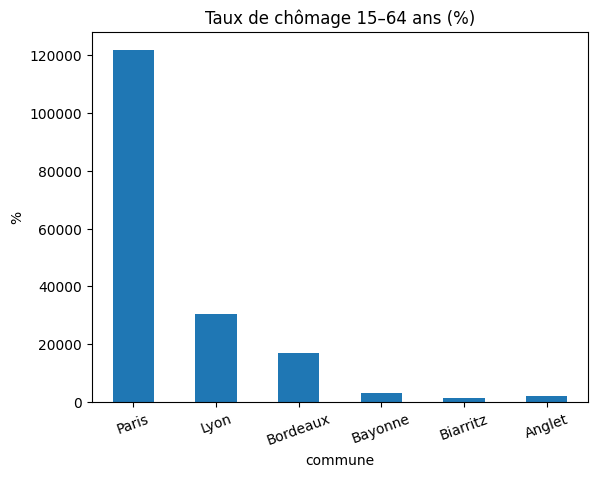

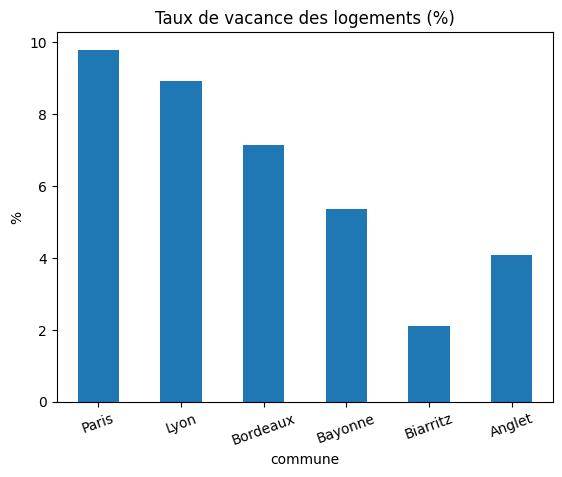

In [21]:
# === Cellule 12 : graphiques ===
import matplotlib.pyplot as plt

# Revenu médian
if "revenu_median_2021" in df_merged.columns:
    df_merged.plot(kind="bar", x="commune", y="revenu_median_2021", legend=False)
    plt.title("Revenu médian (2021)")
    plt.ylabel("€")
    plt.xticks(rotation=20)
    plt.show()

# Taux de chômage
if "taux_chomage_15_64" in df_merged.columns:
    df_merged.plot(kind="bar", x="commune", y="taux_chomage_15_64", legend=False)
    plt.title("Taux de chômage 15–64 ans (%)")
    plt.ylabel("%")
    plt.xticks(rotation=20)
    plt.show()

# Taux de vacance
if "taux_vacance_%" in df_merged.columns:
    df_merged.plot(kind="bar", x="commune", y="taux_vacance_%", legend=False)
    plt.title("Taux de vacance des logements (%)")
    plt.ylabel("%")
    plt.xticks(rotation=20)
    plt.show()

In [23]:
!pip3 install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl (11.1 MB)
  Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [24]:
# === Cellule 13 : score de contexte (optionnel) ===
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features_pos = []  # variables positives pour Airbnb
if "densite_hab_km2" in df_merged: features_pos.append("densite_hab_km2")
if "revenu_median_2021" in df_merged: features_pos.append("revenu_median_2021")

features_neg = []  # variables négatives (plus c'est haut, moins c'est favorable)
if "taux_chomage_15_64" in df_merged: features_neg.append("taux_chomage_15_64")
if "taux_pauvrete_2021" in df_merged: features_neg.append("taux_pauvrete_2021")

all_feats = features_pos + features_neg
Z = df_merged[all_feats].copy()

# Min-max 0–1
Z_scaled = pd.DataFrame(scaler.fit_transform(Z), columns=all_feats)

# Score = moyenne des (+) moins moyenne des (–)
score = 0
if features_pos:
    score += Z_scaled[features_pos].mean(axis=1)
if features_neg:
    score -= Z_scaled[features_neg].mean(axis=1)

df_merged["score_contexte_airbnb"] = (score * 100).round(1)
df_merged.sort_values("score_contexte_airbnb", ascending=False)[["commune","score_contexte_airbnb"] + cols_show[1:]]

,commune,score_contexte_airbnb,population_municipale,revenu_median_2021,taux_pauvrete_2021,taux_chomage_15_64,densite_hab_km2,taux_vacance_%,part_res_principales_%
5,Anglet,20,41153,"25,060",10,"2,026","1,570",4,80
0,Paris,7,2133111,"29,730",16,"121,919","20,054",10,80
4,Biarritz,5,25764,"25,640",13,"1,299","2,214",2,57
1,Lyon,-7,522250,"25,430",16,"30,486","10,879",9,85
2,Bordeaux,-27,261804,"24,870",17,"16,952","5,375",7,87
3,Bayonne,-48,52749,"21,780",17,"2,928","2,459",5,90


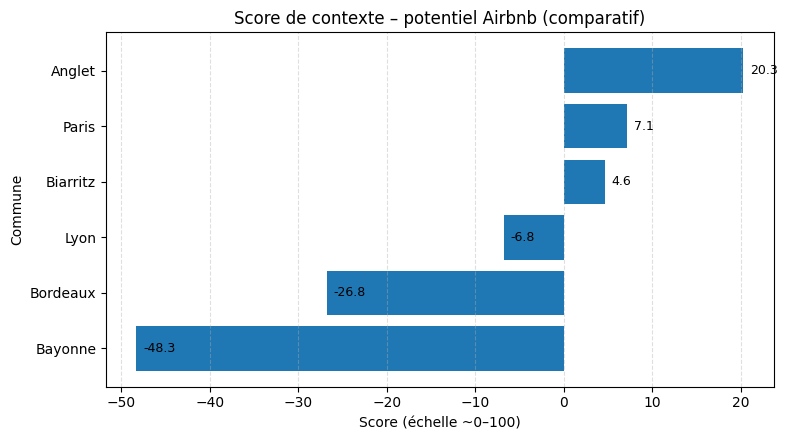

In [25]:
# === Cellule 15 : bar chart du score ===
import matplotlib.pyplot as plt

if "score_contexte_airbnb" not in df_merged.columns:
    raise ValueError("Le champ 'score_contexte_airbnb' n'existe pas. Exécute d'abord la Cellule 13.")

# Trier par score décroissant
plot_df = df_merged[["commune","score_contexte_airbnb"]].dropna().sort_values("score_contexte_airbnb", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["commune"].astype(str), plot_df["score_contexte_airbnb"].astype(float))
ax.set_title("Score de contexte – potentiel Airbnb (comparatif)")
ax.set_xlabel("Score (échelle ~0–100)")
ax.set_ylabel("Commune")
# ajouter les valeurs au bout des barres
for i, (name, val) in enumerate(zip(plot_df["commune"], plot_df["score_contexte_airbnb"])):
    ax.text(val + 0.8, i, f"{val:.1f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

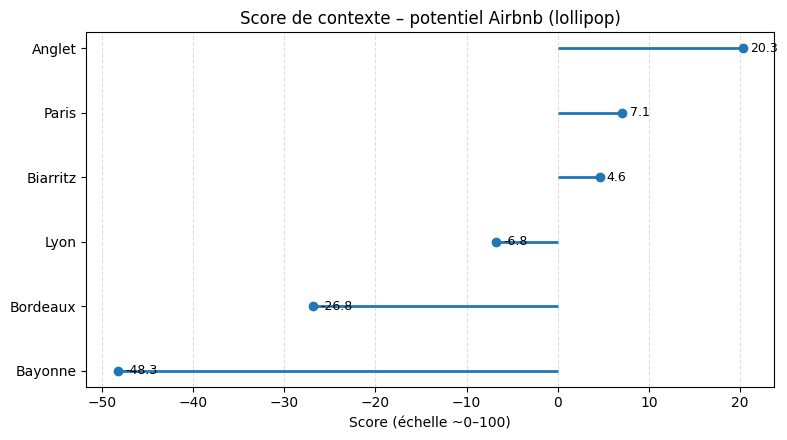

In [26]:
# === Cellule 16 : lollipop chart du score ===
import matplotlib.pyplot as plt

plot_df = df_merged[["commune","score_contexte_airbnb"]].dropna().sort_values("score_contexte_airbnb", ascending=True)
y = range(len(plot_df))

fig, ax = plt.subplots(figsize=(8, 4.5))
# tige
ax.hlines(y=y, xmin=0, xmax=plot_df["score_contexte_airbnb"], linewidth=2)
# point
ax.plot(plot_df["score_contexte_airbnb"], y, "o")  # style par défaut
ax.set_yticks(y)
ax.set_yticklabels(plot_df["commune"].astype(str))
ax.set_xlabel("Score (échelle ~0–100)")
ax.set_title("Score de contexte – potentiel Airbnb (lollipop)")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# labels de valeurs
for i, v in enumerate(plot_df["score_contexte_airbnb"]):
    ax.text(v + 0.8, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
!pip3 install folium

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 113 kB 15.4 MB/s eta 0:00:01
     |████████████████████████████████| 92 kB 6.4 MB/s  eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [29]:
# === Cellule 17 : Folium + coordonnées ===
# Installer si nécessaire (sinon commente cette ligne après 1ère utilisation)
import folium

# Table des coordonnées (lat, lon) des 6 communes
coords = {
    "Paris":    (48.8566, 2.3522),
    "Lyon":     (45.7640, 4.8357),
    "Bordeaux": (44.8378, -0.5792),
    "Bayonne":  (43.4929, -1.4748),
    "Biarritz": (43.4832, -1.5586),
    "Anglet":   (43.4850, -1.5190),
}

# Vérifier que df_merged contient bien nos communes
print(df_merged[["commune"]].drop_duplicates())

    commune
0     Paris
1      Lyon
2  Bordeaux
3   Bayonne
4  Biarritz
5    Anglet


/Users/saife/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [30]:
# === Cellule 18 : préparation des données pour la carte ===
# On sélectionne les colonnes utiles (selon ce que tu as)
cols_map = ["commune","population_municipale","population_2022",
            "revenu_median_2021","taux_chomage_15_64","taux_pauvrete_2021",
            "taux_vacance_%","part_res_principales_%","densite_hab_km2","score_contexte_airbnb"]

cols_map = [c for c in cols_map if c in df_merged.columns]
map_df = df_merged[cols_map].copy()

# Ajouter lat/lon
map_df["lat"] = map_df["commune"].map(lambda x: coords.get(str(x), (None,None))[0])
map_df["lon"] = map_df["commune"].map(lambda x: coords.get(str(x), (None,None))[1])

# Choisir l’indicateur pour la taille/couleur des marqueurs
indicator = "score_contexte_airbnb" if "score_contexte_airbnb" in map_df.columns else "population_municipale"

# Normalisation simple pour taille des cercles
v = map_df[indicator].astype(float)
v_min, v_max = v.min(), v.max()
# taille min/max en pixels
size_min, size_max = 6, 22
sizes = size_min + ( (v - v_min) / (v_max - v_min + 1e-9) ) * (size_max - size_min)
map_df["marker_size"] = sizes

map_df

,commune,population_municipale,population_2022,revenu_median_2021,taux_chomage_15_64,taux_pauvrete_2021,taux_vacance_%,part_res_principales_%,densite_hab_km2,score_contexte_airbnb,lat,lon,marker_size
0,Paris,2133111,"2,113,705","29,730","121,919",16,10,80,"20,054",7,49,2,19
1,Lyon,522250,"520,774","25,430","30,486",16,9,85,"10,879",-7,46,5,16
2,Bordeaux,261804,"265,328","24,870","16,952",17,7,87,"5,375",-27,45,-1,11
3,Bayonne,52749,"53,312","21,780","2,928",17,5,90,"2,459",-48,43,-1,6
4,Biarritz,25764,"25,810","25,640","1,299",13,2,57,"2,214",5,43,-2,18
5,Anglet,41153,"42,288","25,060","2,026",10,4,80,"1,570",20,43,-2,22


In [32]:
# -- PATCH : forcer lat/lon et l'indicateur en float --
map_df["lat"] = pd.to_numeric(map_df["lat"], errors="coerce")
map_df["lon"] = pd.to_numeric(map_df["lon"], errors="coerce")

# s'assurer que l'indicateur est bien numérique
map_df[indicator] = pd.to_numeric(map_df[indicator], errors="coerce")

# (optionnel) vérifier les types
print(map_df.dtypes[["commune","lat","lon"]].to_string())

commune    category
lat         float64
lon         float64


In [35]:
# === Cellule 19 (corrigée et complète) : carte Folium ===
import numpy as np
import folium
import pandas as pd

# Forcer lat/lon et l'indicateur en float
map_df["lat"] = pd.to_numeric(map_df["lat"], errors="coerce")
map_df["lon"] = pd.to_numeric(map_df["lon"], errors="coerce")
map_df[indicator] = pd.to_numeric(map_df[indicator], errors="coerce")

# Filtrer les lignes avec coordonnées valides
mf = map_df.dropna(subset=["lat", "lon"]).copy()

# Centre carte : moyenne des lat/lon (en float)
center_lat = float(np.nanmean(mf["lat"].astype(float).to_numpy()))
center_lon = float(np.nanmean(mf["lon"].astype(float).to_numpy()))

# Créer la carte
m = folium.Map(location=[center_lat, center_lon], zoom_start=5.5, tiles="cartodbpositron")

# Échelles min/max pour la couleur
v = mf[indicator].astype(float)
v_min, v_max = float(np.nanmin(v)), float(np.nanmax(v))

def color_scale(val, vmin, vmax):
    """Retourne une couleur selon la valeur normalisée."""
    if val is None or np.isnan(val) or vmax == vmin:
        return "#888888"
    q = (val - vmin) / (vmax - vmin + 1e-9)
    if q < 0.33:
        return "#e74c3c"  # rouge
    elif q < 0.66:
        return "#f39c12"  # orange
    else:
        return "#27ae60"  # vert

# Ajouter les marqueurs
for _, row in mf.iterrows():
    val = float(row[indicator]) if pd.notna(row[indicator]) else None
    clr = color_scale(val, v_min, v_max)

    popup_lines = [f"<b>{row['commune']}</b>"]
    if "population_municipale" in mf.columns and pd.notna(row.get("population_municipale")):
        popup_lines.append(f"Population municipale: {int(row['population_municipale']):,}".replace(",", " "))
    if "population_2022" in mf.columns and pd.notna(row.get("population_2022")):
        popup_lines.append(f"Population 2022: {int(row['population_2022']):,}".replace(",", " "))
    if "revenu_median_2021" in mf.columns and pd.notna(row.get("revenu_median_2021")):
        popup_lines.append(f"Revenu médian 2021: {row['revenu_median_2021']:.0f} €")
    if "taux_chomage_15_64" in mf.columns and pd.notna(row.get("taux_chomage_15_64")):
        popup_lines.append(f"Chômage 15–64: {row['taux_chomage_15_64']:.1f} %")
    if "taux_pauvrete_2021" in mf.columns and pd.notna(row.get("taux_pauvrete_2021")):
        popup_lines.append(f"Pauvreté: {row['taux_pauvrete_2021']:.1f} %")
    if "taux_vacance_%" in mf.columns and pd.notna(row.get("taux_vacance_%")):
        popup_lines.append(f"Vacance logements: {row['taux_vacance_%']:.1f} %")
    if "densite_hab_km2" in mf.columns and pd.notna(row.get("densite_hab_km2")):
        popup_lines.append(f"Densité: {row['densite_hab_km2']:.0f} hab/km²")
    if "score_contexte_airbnb" in mf.columns and pd.notna(row.get("score_contexte_airbnb")):
        popup_lines.append(f"<b>Score Airbnb:</b> {row['score_contexte_airbnb']:.1f}")

    folium.CircleMarker(
        location=(float(row["lat"]), float(row["lon"])),
        radius=float(row["marker_size"]),
        popup=folium.Popup("<br>".join(popup_lines), max_width=300),
        tooltip=f"{row['commune']} — {indicator}: {val:.1f}" if val is not None else row["commune"],
        color=clr,
        fill=True,
        fill_opacity=0.7,
    ).add_to(m)

# Légende HTML
legend_html = f"""
<div style="position: fixed; bottom: 30px; left: 30px; width: 220px; 
            z-index:9999; font-size:12px; background: white; border:1px solid #999; 
            border-radius: 6px; padding: 10px;">
<b>Légende</b><br>
• Couleur = niveau de {indicator.replace('_',' ')}<br>
• Taille = normalisée sur {indicator.replace('_',' ')}<br>
Min: {v_min:.1f} — Max: {v_max:.1f}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ✅ Sauvegarde + affichage direct
map_file = "carte_potentiel_airbnb.html"
m.save(map_file)
print(f"✅ Carte sauvegardée dans : {map_file}")

# Affichage dans la cellule
m

✅ Carte sauvegardée dans : carte_potentiel_airbnb.html
